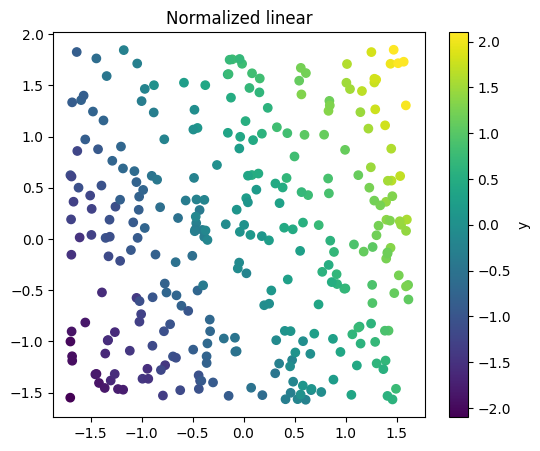

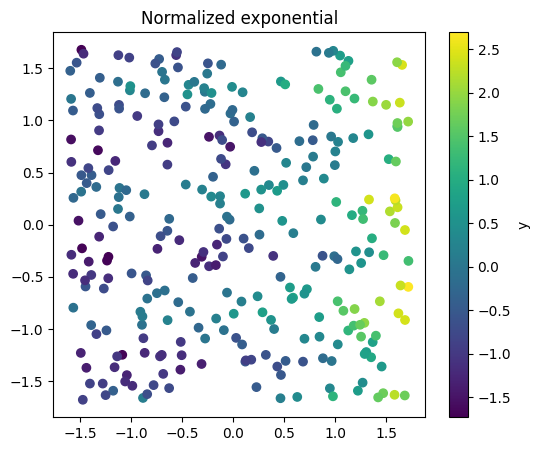

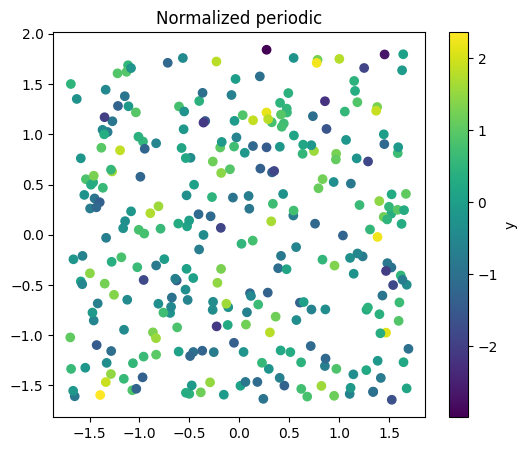

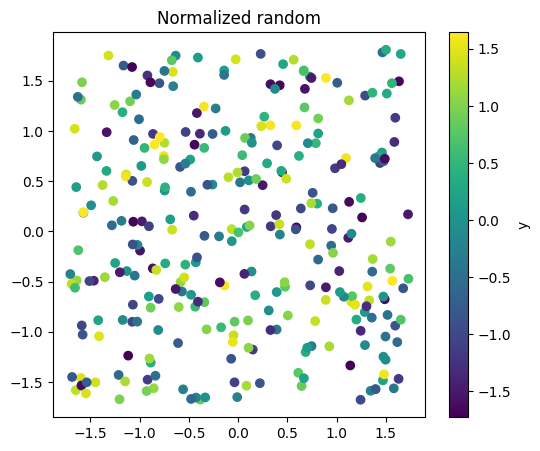

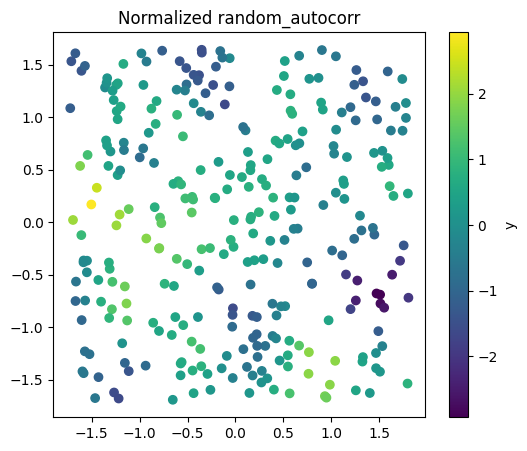


=== Comparison of CV methods ===

       Function       Random CV      Spatial CV Importance-weighted CV KMM-weighted spatial CV
         linear 0.0067 ± 0.0009 0.0067 ± 0.0009        0.0078 ± 0.0014         0.0070 ± 0.0011
    exponential 0.3837 ± 0.0299 0.4833 ± 0.1180        0.7498 ± 0.5784         0.4931 ± 0.1595
       periodic 1.0263 ± 0.1024 1.0235 ± 0.2113        1.1595 ± 0.2280         1.1656 ± 0.2265
         random 1.0052 ± 0.1578 1.0102 ± 0.0314        1.3053 ± 0.3765         1.0697 ± 0.0849
random_autocorr 0.9454 ± 0.1790 1.2316 ± 0.5302        2.5865 ± 1.7302         1.1797 ± 0.2493

Results saved to results.json


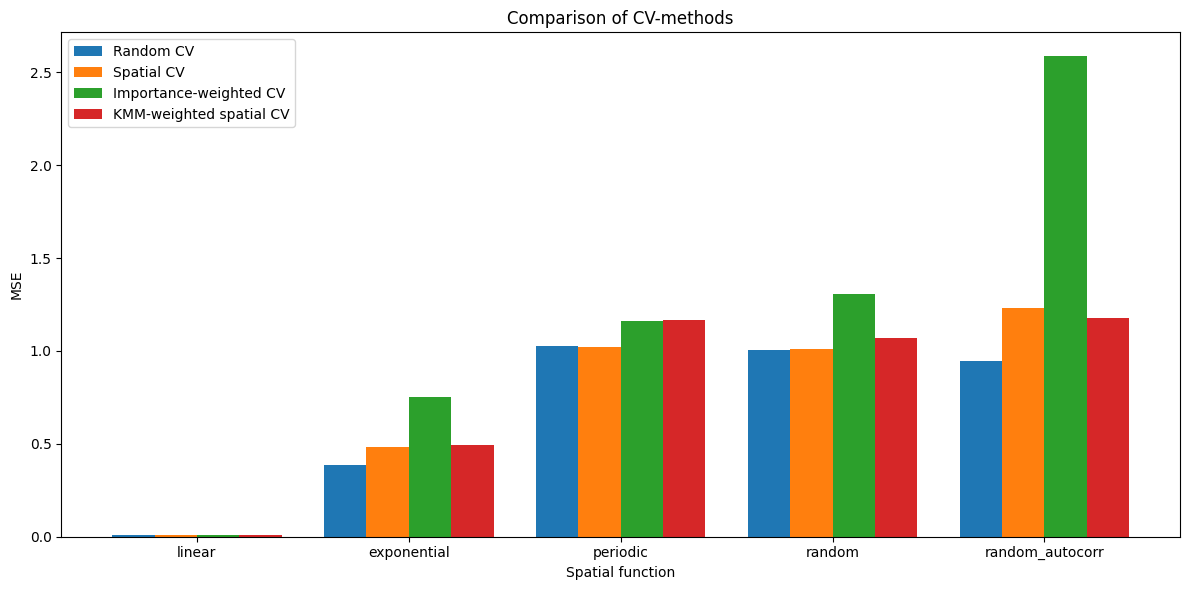

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from CV_Methods import run_comparison

results, df_results = run_comparison(n_folds=5, n_samples=300, noise_std=0.3, gamma=0.5, B=10)

print("\n=== Comparison of CV methods ===\n")
print(df_results.to_string(index=False))

with open("results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)
print("\nResults saved to results.json")

plt.figure(figsize=(12, 6))
funcs = df_results['Function'].values
methods = ['Random CV', 'Spatial CV', 'Importance-weighted CV', 'KMM-weighted spatial CV']
data = np.zeros((len(funcs), len(methods)))
for i, func in enumerate(funcs):
    for j, meth in enumerate(methods):
        val = float(df_results[df_results['Function'] == func][meth].values[0].split(' ± ')[0])
        data[i, j] = val

x = np.arange(len(funcs))
width = 0.2
for j, meth in enumerate(methods):
    plt.bar(x + j * width, data[:, j], width, label=meth)

plt.xlabel('Spatial function')
plt.ylabel('MSE')
plt.title('Comparison of CV-methods')
plt.xticks(x + width * 1.5, funcs)
plt.legend()
plt.tight_layout()
plt.show()